# UK Biobank research content, 2013–2025

This is the single active content-analysis notebook. It consolidates the BERTopic and category-flow notebooks, preserved under `_archived/`.

The main figure places **A, FOR Level 4 composition** and **B, RCDC composition** side by side, with **C, thematic topic waves** below. Two supplements show annual category detail and classification coverage/breadth; a third shows topic-model robustness when its verified diagnostics are available. Figures use the shared project palette, Helvetica, bold left-aligned uppercase titles, and 500-DPI PNG plus PDF exports.

All analysis is restricted to **1 January 2013–31 December 2025 inclusive**. Topic modelling and figure generation are independent: completed topic assignments are checked before any modelling libraries are imported. Existing results are reused, while missing results trigger the preserved five-configuration, five-seed robustness workflow. Invalid or unverified results stop without a silent refit.

Growth tables rank FoRs, RCDC tags and cached topics by 2018–2025 compound annual growth in paper counts. They include recent growth and composition-share changes, with CSV, Excel and editable Word exports. A separate share-gain ranking retains emerging categories with small or zero baseline counts.


In [1]:
from pathlib import Path
import os
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

## 1. Reuse or compute topic results

Completed topic assignments are saved at **`output/bertopic/showcase_plus_id_topics.csv`**, relative to the project root: **23,441 publications, 67 topics, 2013–2025**. The matching `showcase_plus_id_topics.analysis_window.json` validates the saved results. The plots below reuse these assignments without fitting a model.

The same `output/bertopic/` directory contains `bertopic_document_topic_assignments.csv` (detailed assignments), `bertopic_topic_labels.csv` (labels), and the saved seed-robustness and cluster-persistence tables used by the diagnostic supplement.

Leave the defaults for a complete run. Set `RUN_TOPIC_MODELLING = False` to inspect the classification figures without fitting if results are absent. Set `FORCE_TOPIC_REFIT = True` only for an intentional refit.

The cache checks `output/bertopic/` and registered legacy CSV locations. Results must contain stable publication IDs, assignments, and a matching analysis-window provenance sidecar. Cached embeddings alone are not completed topic results. Embeddings and each successful parameter/seed fit are reused independently if a run is interrupted. The original SPECTER cache can be reused only after reproducing its ordered-corpus hash and matching the current documents; the clustering itself uses only the current analysis window.

In [2]:
import json
import pandas as pd

# Completed assignments: output/bertopic/showcase_plus_id_topics.csv
TOPIC_RESULTS_DIR = P.OUTPUT / "bertopic"
RUN_TOPIC_MODELLING = os.environ.get("UKB_RUN_TOPIC_MODELLING", "1") != "0"
FORCE_TOPIC_REFIT = False

from utils import data_analysis_02_content_topics as T
TOPIC_RESULTS = T.ensure_topic_results(
    output_dir=TOPIC_RESULTS_DIR,
    train_if_missing=RUN_TOPIC_MODELLING,
    force=FORCE_TOPIC_REFIT,
)
if TOPIC_RESULTS is not None:
    topic_assignments = pd.read_csv(TOPIC_RESULTS)
    topic_column = "topics" if "topics" in topic_assignments else "topic"
    topic_labels = topic_assignments[topic_column].astype(str).str.strip()
    assigned = ~topic_labels.str.lower().isin(["outlier", "-1", "-1.0"])
    topic_provenance = json.loads(
        TOPIC_RESULTS.with_suffix(".analysis_window.json").read_text())
    print(f"Saved topic results: {len(topic_assignments):,} publications; "
          f"{topic_labels[assigned].nunique():,} topics.")
    print(f"Training years: {topic_provenance['training_min_year']}"
          f"–{topic_provenance['training_max_year']}.")
    print("Plotting data:", P.raw_path(TOPIC_RESULTS))

[SKIP] BERTopic results already exist: output/bertopic/showcase_plus_id_topics.csv
Saved topic results: 23,441 publications; 67 topics.
Training years: 2013–2025.
Plotting data: output/bertopic/showcase_plus_id_topics.csv


## 2. Prepare the shared figure data

FOR composition counts a publication once in each assigned Level 4 field, then divides by all paper–field assignments in that year. RCDC divides one unit per paper across its distinct tags. BERTopic supplies one topic per eligible publication after the existing outlier-reassignment procedure. Missing classifications remain outside composition denominators and are quantified in the coverage supplement.

The main figure uses leading categories selected by total in-window weight; the full distributions remain in the source tables. The topic-wave thickness is the annual share of **all non-outlier topic-assigned publications**, without renormalising the displayed topics to 100%. The vertical baseline is a display convention. Very small early cohorts are explicitly reported.

In [3]:
import matplotlib.pyplot as plt
from IPython.display import display
from utils.shared_style import PNG_DPI, load_style, savefig
from utils.shared_analysis_window import ANALYSIS_START_YEAR, ANALYSIS_END_YEAR
from utils import data_analysis_02_content_panels as C
from utils import data_analysis_02_content_exports as E

STYLE = load_style("02_content")
FLOW_MIN, FLOW_MAX = ANALYSIS_START_YEAR, ANALYSIS_END_YEAR
FLOW_YEARS = list(range(FLOW_MIN, FLOW_MAX + 1))
ARTIFACTS = P.ArtifactRegistry(P.TABLE_CONTENT)
D = C.build_panel_data(topic_results=TOPIC_RESULTS)
display(C.band_summary(D))

corpus  : 23,442 papers, 2013-2025
FOR L4  : 34,025 pairs | 22,793 papers | 113 fields (1.49 codes/paper)
RCDC    : 170,689 pairs | 23,122 papers | 266 tags (7.4 tags/paper)
topics  : 12 bands of 67 hold 40.0-52.4% of each year (mean 46.7%, remainder 53.3% over 55 categories)
FOR L4  : 8 bands of 113 hold 71.3-85.7% of each year (mean 77.1%, remainder 22.9% over 105 categories)
RCDC    : 8 bands of 266 hold 33.3-48.5% of each year (mean 42.9%, remainder 57.1% over 258 categories)


,vocabulary,available,weight,categories,bands_drawn,categories_in_remainder,coverage_mean_pct,coverage_min_pct,coverage_max_pct,remainder_mean_pct,target_other,min_band,max_bands,min_bands
0,BERTopic topics,True,n_papers,67,12,55,46.7,40.0,52.4,53.3,45.0,0.8,12,8
1,FOR 2020 Level 4,True,n_papers,113,8,105,77.1,71.3,85.7,22.9,10.0,0.7,8,8
2,RCDC tags,True,n_frac,266,8,258,42.9,33.3,48.5,57.1,10.0,1.2,8,8


## 3. Fastest-growing fields, RCDC categories and topics

The default comparison is **2018–2025**, matching the main growth figure. Categories are ranked within each vocabulary by compound annual growth rate (CAGR) in **distinct publication counts**, requiring at least **10 papers in 2018** and positive growth. This avoids rankings dominated by changes such as 1→7 papers. At most 20 categories are shown per vocabulary; all categories and eligibility reasons remain in the complete CSV.

The tables also report 2024–2025 growth and changes in composition share. Counts are whole-paper counts for each category; a paper may carry multiple FoRs or RCDC tags. Composition shares retain the figure definitions: FoR paper–field assignments, fractionally weighted RCDC tags, and non-outlier topic assignments. **Percentage growth and percentage-point change in composition are different quantities.**

`content_largest_share_gains.csv` and the Excel share-gain sheets rank positive composition changes with at least 10 end-year papers, retaining categories with small or zero baseline counts. No growth ratio is assigned to a zero baseline. Missing classification years remain missing. Change the settings below to compare other years within 2013–2025.

Exports go to `output/tables/02_content/`: one ranked CSV and editable Word table per vocabulary, a combined Excel workbook, all-category statistics and methods. This cell uses `D` and never reruns BERTopic.


In [4]:
from utils import data_analysis_02_content_growth as G

GROWTH_BASELINE_YEAR = 2018
GROWTH_END_YEAR = 2025
GROWTH_MIN_BASELINE_PAPERS = 10
GROWTH_TOP_N = 20

growth_tables = G.export_growth_tables(
    D, ARTIFACTS,
    baseline_year=GROWTH_BASELINE_YEAR,
    end_year=GROWTH_END_YEAR,
    min_baseline_papers=GROWTH_MIN_BASELINE_PAPERS,
    top_n=GROWTH_TOP_N,
)
for vocabulary, view in growth_tables["views"].items():
    print(f"{G.VOCABULARIES[vocabulary][0]}: {len(view)} fastest-growing categories")
    display(view)


saved output/tables/02_content/content_fastest_growing_for_l4.docx
saved output/tables/02_content/content_fastest_growing_rcdc.docx
saved output/tables/02_content/content_fastest_growing_topics.docx
saved output/tables/02_content/content_category_growth_all.csv
saved output/tables/02_content/content_fastest_growing_categories.csv
saved output/tables/02_content/content_largest_share_gains.csv
saved output/tables/02_content/content_fastest_growing_for_l4.csv
saved output/tables/02_content/content_fastest_growing_rcdc.csv
saved output/tables/02_content/content_fastest_growing_topics.csv
saved output/tables/02_content/content_growth_tables.xlsx
saved output/tables/02_content/content_growth_methods.txt
FoR Level 4: 11 fastest-growing categories


,Rank,Papers 2018,Papers 2025,Annualised growth (%),Growth 2024–2025 (%),Share 2018 (%),Share 2025 (%),Change (pp)
Category,,,,,,,,
Nutrition and Dietetics,1,17,308,51.3,10.4,1.86,3.69,1.83
Cardiovascular Medicine and Haematology,2,32,559,50.5,33.1,3.50,6.70,3.20
Clinical Sciences,3,95,1537,48.8,19.7,10.41,18.43,8.03
Health Services and Systems,4,22,310,45.9,23.0,2.41,3.72,1.31
Oncology and Carcinogenesis,5,31,359,41.9,35.5,3.40,4.31,0.91
Public Health,6,52,482,37.5,37.7,5.70,5.78,0.08
Biological Psychology,7,67,513,33.7,16.1,7.34,6.15,-1.19
Epidemiology,8,185,1367,33.1,11.4,20.26,16.39,-3.87
Pharmacology and Pharmaceutical Sciences,9,20,121,29.3,13.1,2.19,1.45,-0.74


RCDC: 20 fastest-growing categories


,Rank,Papers 2018,Papers 2025,Annualised growth (%),Growth 2024–2025 (%),Share 2018 (%),Share 2025 (%),Change (pp)
Category,,,,,,,,
Social Determinants of Health,1,11,295,60.0,43.2,0.22,0.58,0.37
Health Disparities,2,29,772,59.8,39.9,0.60,1.52,0.91
Minority Health,3,16,397,58.2,16.8,0.33,0.72,0.39
Dementia,4,25,612,57.9,28.6,0.33,0.83,0.51
Health Disparities and Racial or Ethnic Minority Health Research,5,41,1000,57.8,35.1,1.18,2.02,0.84
Cerebrovascular,6,15,360,57.5,28.6,0.26,0.53,0.28
Rare Diseases,7,22,526,57.4,34.2,0.51,1.19,0.69
Neurodegenerative,8,40,939,57.0,30.6,0.66,1.54,0.88
Acquired Cognitive Impairment,9,27,630,56.8,28.0,0.36,0.87,0.51


BERTopic: 20 fastest-growing categories


,Rank,Papers 2018,Papers 2025,Annualised growth (%),Growth 2024–2025 (%),Share 2018 (%),Share 2025 (%),Change (pp)
Category,,,,,,,,
Diet and nutrition,1,10,184,51.6,12.9,1.62,3.12,1.50
Vision and eye disease,2,14,202,46.4,20.2,2.27,3.43,1.16
Physical activity and sedentary behaviour,3,12,172,46.3,68.6,1.95,2.92,0.97
Air pollution and environmental exposure,4,14,183,44.4,25.3,2.27,3.11,0.83
Cancer risk and genetic susceptibility,5,12,139,41.9,17.8,1.95,2.36,0.41
"Cognition, dementia and brain imaging",6,77,827,40.4,21.8,12.50,14.04,1.54
Depression and mental health,7,42,360,35.9,23.3,6.82,6.11,-0.71
ehr / multimorbidity / llms / graph,8,10,83,35.3,31.7,1.62,1.41,-0.21
Lung function and respiratory disease,9,16,130,34.9,19.3,2.60,2.21,-0.39


## 4. Main figure: research composition and thematic waves

Panels are drawn directly from the shared aggregates. Rerunning this cell changes the figure without fitting a topic model. Full model labels, reviewed display descriptors and label sources are retained in `content_topic_labels.csv`.

saved output/figures/data_analysis/02_content/02_01_figure_01_content_composition.pdf
saved output/figures/data_analysis/02_content/02_01_figure_01_content_composition.png


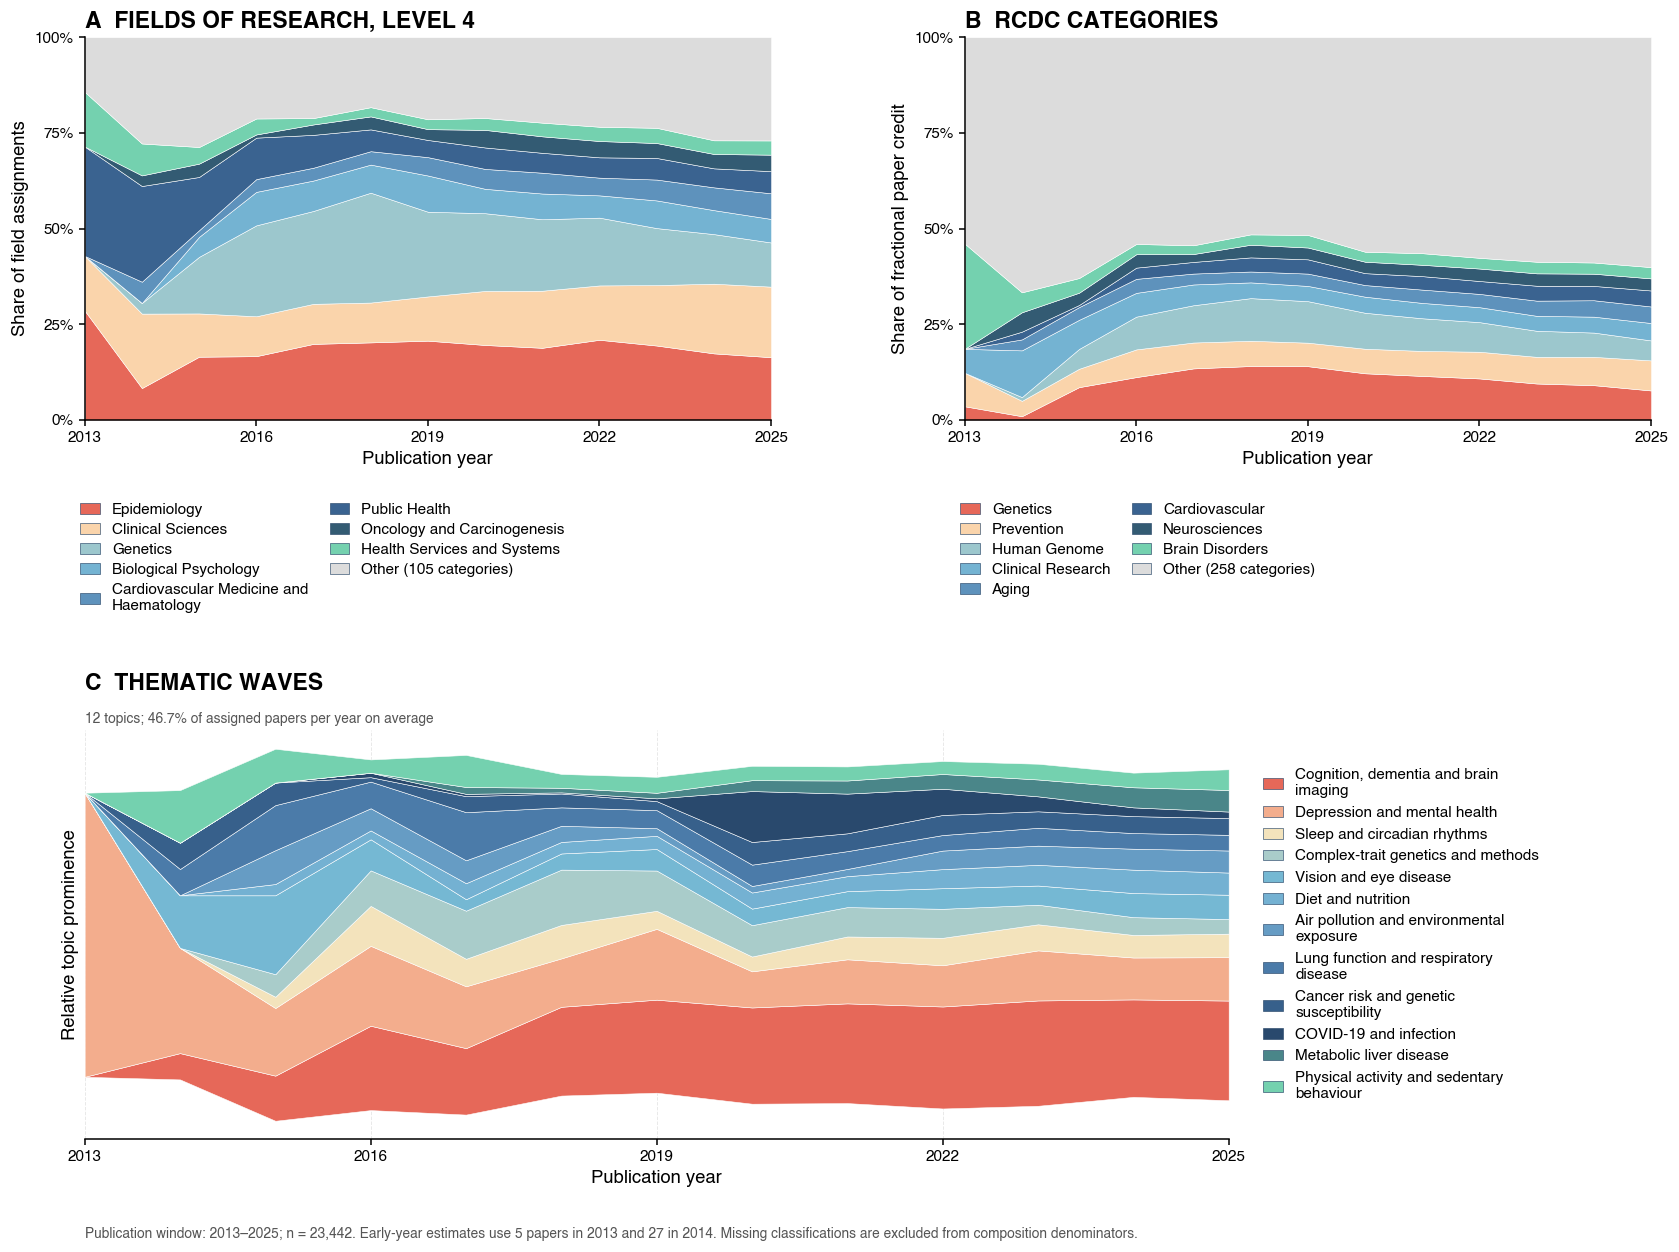

In [5]:
fig = C.figure_main(D, save=False)
main_stem = "02_01_figure_01_content_composition"
if not D["topics"]["available"]:
    main_stem += "_incomplete"
    print("[WARN] Topic results are absent; this is an incomplete preview.")
ARTIFACTS.record_figures(savefig(fig, main_stem, style=STYLE))
display(fig)
plt.close(fig)

## 5. Supplementary figure: annual category detail

Annual shares of the twelve leading fields and RCDC tags, with percentage annotations and cell borders. The shared cool–cream–red colormap spans the full observed range within each panel. These are whole-vocabulary shares, so the twelve displayed rows need not sum to 100%.

saved output/figures/data_analysis/02_content/02_02_supplementary_figure_01_category_composition.pdf
saved output/figures/data_analysis/02_content/02_02_supplementary_figure_01_category_composition.png


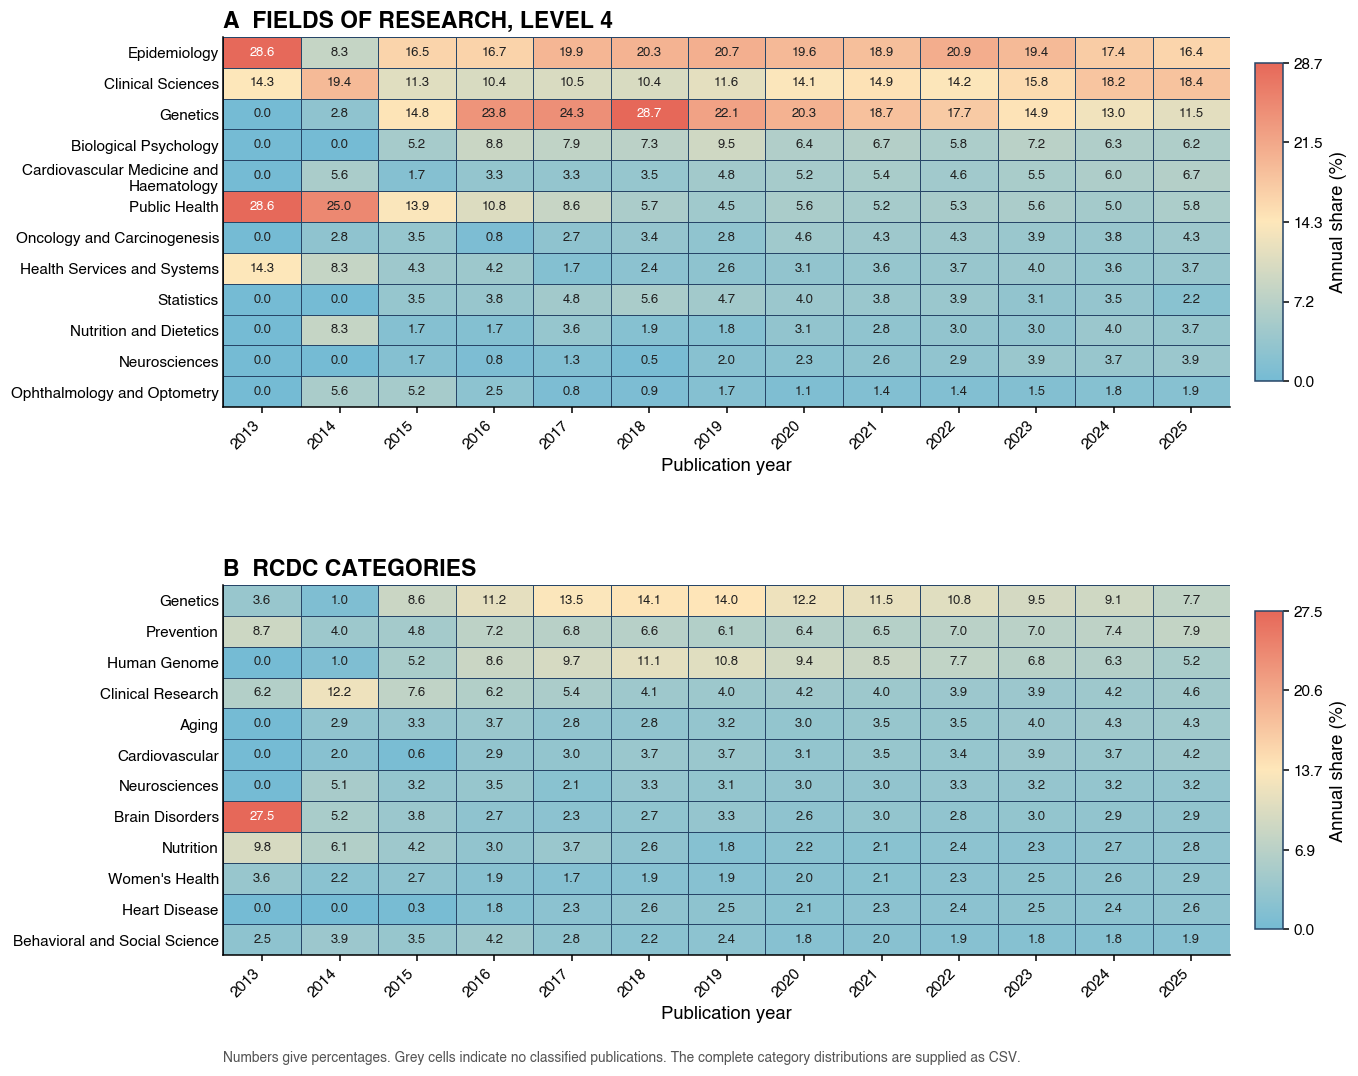

In [6]:
fig = C.figure_si_category_changes(D, save=False)
ARTIFACTS.record_figures(savefig(
    fig, "02_02_supplementary_figure_01_category_composition", style=STYLE))
display(fig)
plt.close(fig)

## 6. Supplementary figure: coverage and breadth

Coverage uses all papers in each year as denominator. Diversity is the exponential of Shannon entropy. Annual and cumulative category counts describe each vocabulary separately; different vocabularies have different granularity, and counts are not equivalent units. These descriptive measures also depend on corpus size.

saved output/figures/data_analysis/02_content/02_03_supplementary_figure_02_coverage_and_breadth.pdf
saved output/figures/data_analysis/02_content/02_03_supplementary_figure_02_coverage_and_breadth.png


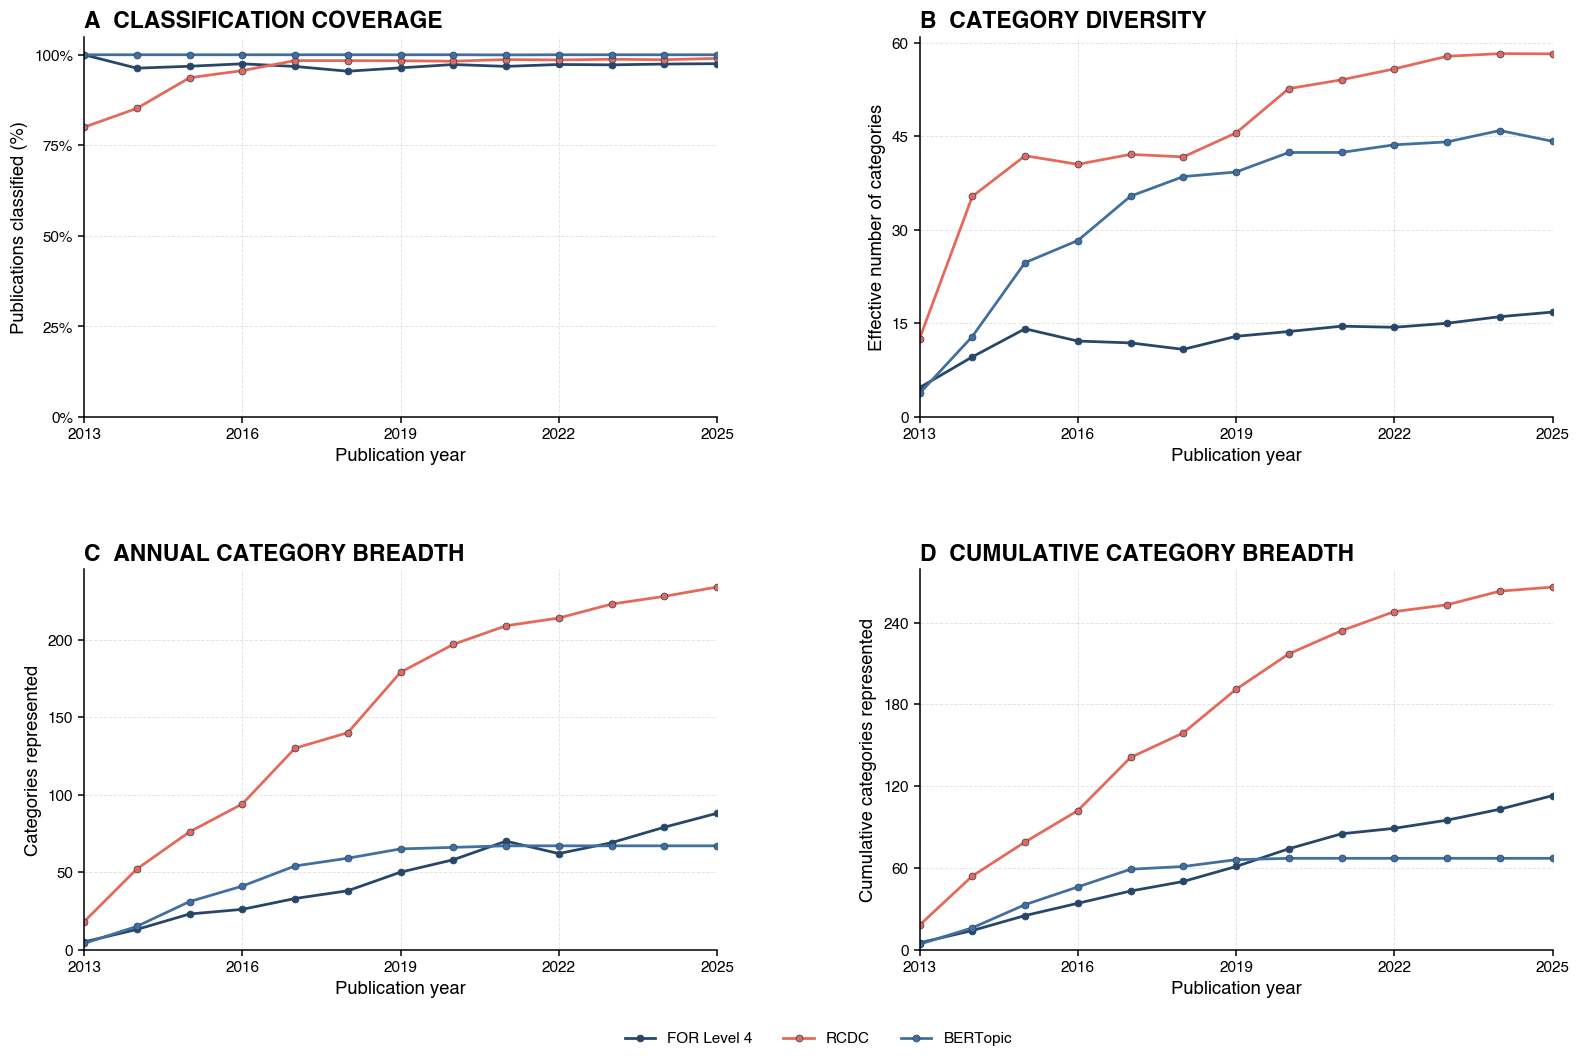

In [7]:
fig = C.figure_si_breadth_coverage(D, save=False)
ARTIFACTS.record_figures(savefig(
    fig, "02_03_supplementary_figure_02_coverage_and_breadth", style=STYLE))
display(fig)
plt.close(fig)

## 7. Supplementary figure: topic-model robustness

When the completed run supplies verified diagnostics, report variation across the five parameter configurations and five seeds, assignment stability, and final HDBSCAN cluster persistence. Diagnostic plots read saved tables and never fit a model. The representative seed is the assignment medoid under adjusted Rand agreement; the primary parameter score combines coherence, diversity, outlier rate, topic-count penalty and between-seed stability. Persistence is an additional diagnostic.

saved output/figures/data_analysis/02_content/02_04_supplementary_figure_03_topic_robustness.pdf
saved output/figures/data_analysis/02_content/02_04_supplementary_figure_03_topic_robustness.png


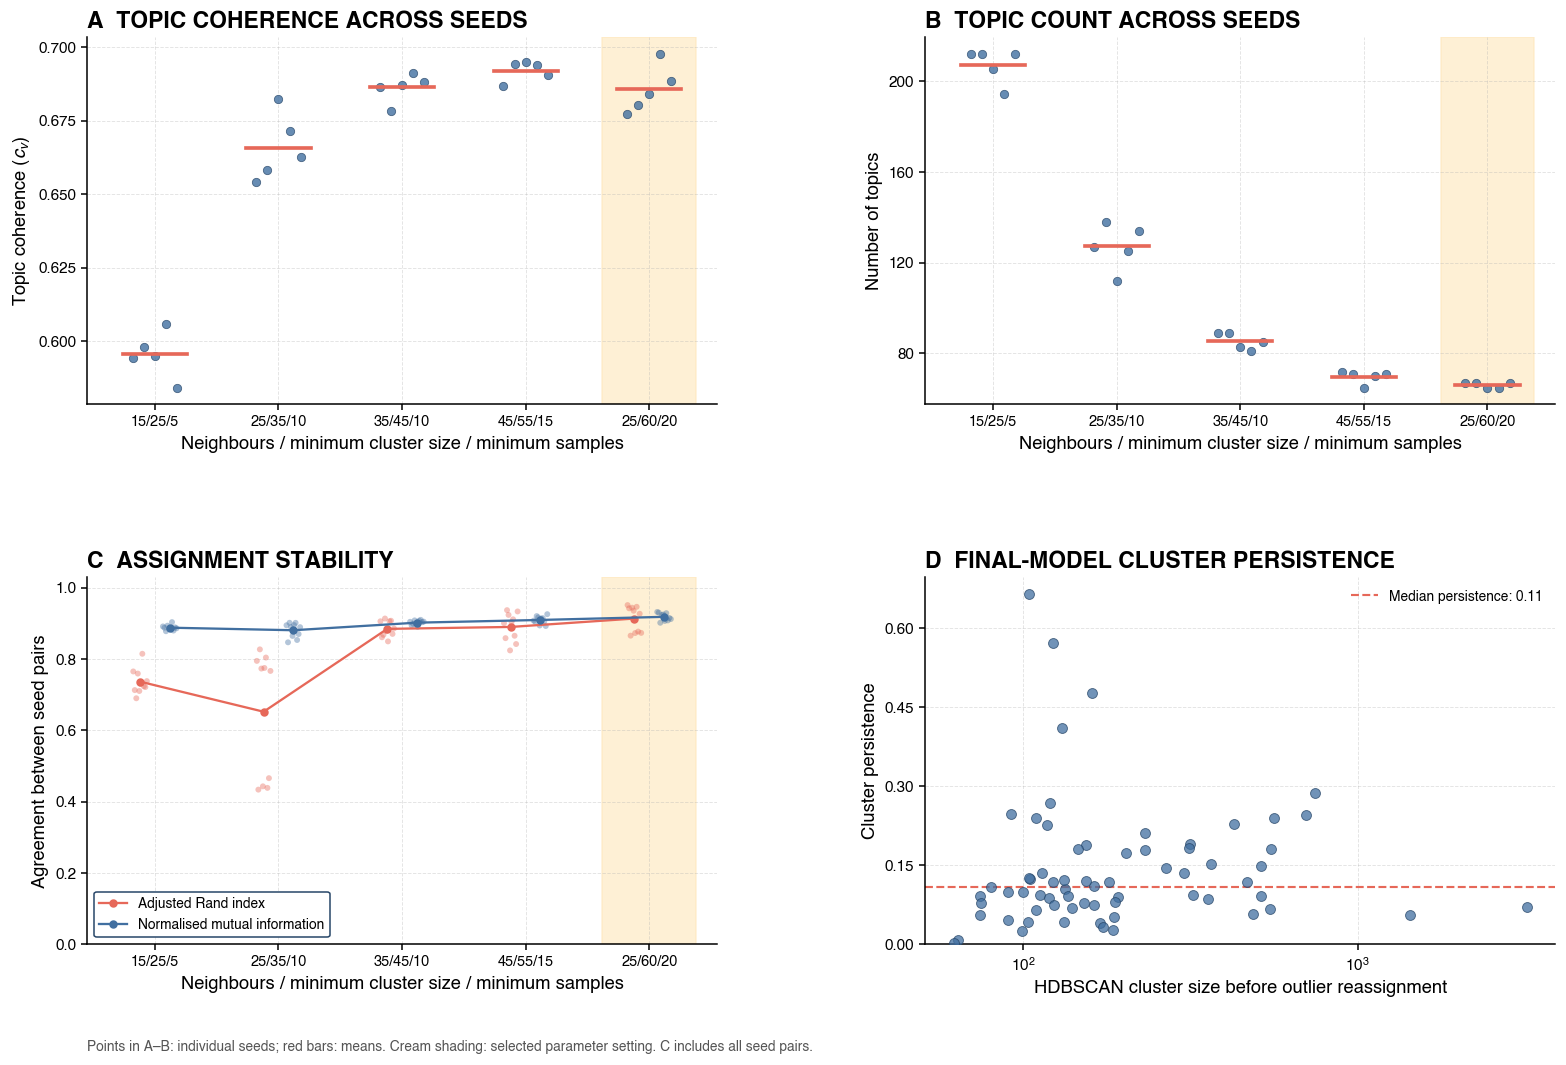

In [8]:
diagnostics = C.load_topic_diagnostics(D)
if diagnostics is not None:
    fig = C.figure_si_topic_robustness(D, save=False)
    ARTIFACTS.record_figures(savefig(
        fig, "02_04_supplementary_figure_03_topic_robustness", style=STYLE))
    display(fig)
    plt.close(fig)
else:
    print("[SKIP] Verified topic-model robustness diagnostics are unavailable.")

## 8. Source tables, captions and manifest

Exports include full annual category distributions, denominators, category-share changes, displayed-band coverage, topic labels and analysis parameters. The caption and methods files document weighting, selection and the treatment of missing data. Figures are PNG/PDF; source tables are CSV, and growth rankings additionally have Excel and editable Word exports. JSON sidecars are used only for model-cache provenance.

The consolidated workflow removes the old hard-coded historical count comparisons and duplicate standalone figures. Earlier notebook implementations remain available in `_archived/` for reference.

In [9]:
tables = E.export_content_tables(D, ARTIFACTS)
manifest, manifest_path = ARTIFACTS.save_manifest("02_content_manifest.csv")
print(f"Exported {len(ARTIFACTS.figure_paths)} figure files and "
      f"{len(ARTIFACTS.table_paths)} tables/captions; PNG resolution {PNG_DPI} DPI.")
print("Manifest:", P.raw_path(manifest_path))

saved output/tables/02_content/content_annual_category_shares.csv
saved output/tables/02_content/content_category_share_changes.csv
saved output/tables/02_content/content_annual_coverage_and_breadth.csv
saved output/tables/02_content/content_displayed_band_coverage.csv
saved output/tables/02_content/content_topic_labels.csv
saved output/tables/02_content/for_l4_year_share.csv
saved output/tables/02_content/for_l4_year_weights.csv
saved output/tables/02_content/rcdc_year_share.csv
saved output/tables/02_content/rcdc_year_weights.csv
saved output/tables/02_content/bertopic_year_share.csv
saved output/tables/02_content/bertopic_year_weights.csv
saved output/tables/02_content/content_analysis_parameters.csv
saved output/tables/02_content/content_topic_diagnostics_runs.csv
saved output/tables/02_content/content_topic_diagnostics_summary.csv
saved output/tables/02_content/content_topic_diagnostics_pairs.csv
saved output/tables/02_content/content_topic_diagnostics_persistence.csv
saved output